In [37]:
import pandas as pd 
import numpy as np

df = pd.read_csv('ncaa_data.csv')

In [38]:
df.head()

,game_id,period,game_clock,home_name,home_score,away_score,away_name,home_score_differential,total_seconds_remaining,home_team_wins
0,000872e5-f02a-4b64-ac73-b6b1a7ad10ec,1,19:39,Gators,19.0,9.0,Bulldogs,10.0,2379,0
1,000872e5-f02a-4b64-ac73-b6b1a7ad10ec,1,19:37,Gators,19.0,9.0,Bulldogs,10.0,2377,0
2,000872e5-f02a-4b64-ac73-b6b1a7ad10ec,1,19:22,Gators,19.0,10.0,Bulldogs,9.0,2362,0
3,000872e5-f02a-4b64-ac73-b6b1a7ad10ec,1,19:22,Gators,19.0,10.0,Bulldogs,9.0,2362,0
4,000872e5-f02a-4b64-ac73-b6b1a7ad10ec,1,19:22,Gators,19.0,10.0,Bulldogs,9.0,2362,0


In [39]:
df.columns

Index(['game_id', 'period', 'game_clock', 'home_name', 'home_score',
       'away_score', 'away_name', 'home_score_differential',
       'total_seconds_remaining', 'home_team_wins'],
      dtype='object')

In [40]:
# Defining the feature (X) 
X = df.drop(columns=['home_team_wins'])
# Defining target variable 
y = df['home_team_wins']

In [41]:

from sklearn.model_selection import GroupShuffleSplit
# Initializing my split 80/20
gss = GroupShuffleSplit(n_splits=1,train_size = 0.8,test_size= 0.2, random_state=42)
## Here we are defining the random train/test split. Do 1 split of 80/20. Random State set to 42 to split the same way in the future 

# Getting the indeces of the split, grouping by game_id 
train_idx, test_idx = next(gss.split(X, y , groups=X['game_id']))
## gss.split is splitting the inputted data on the basis of game_id
## next() is telling to do the spit. The result is the row numbers for the training set and the testing set 
## The package contains two lists so we provide two varaible names seperated by a comma. The first list of numbers goes to train_idx, the second to test_idx 


In [42]:
## Creating the final leakage free training and testing sets 
## train_idx and test_idx are just arrays of row numbers, do not contian actual data. 
## iloc stands for indeger location. It looks up rows by their numberic order starting at 0 
## This code is telling pandas to go into X DataFrame, look at the integer location of every row, and extract only 
### the rows whose numerical pisition match ht enumbers in my train_idx. 
X_train = X.iloc[train_idx] 
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [43]:
## Dropping the remaining non-numeric and identifier columns before training 
cols_to_drop = ['game_id', 'home_name', 'away_name', 'game_clock']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)


In [44]:
X_train

,period,home_score,away_score,home_score_differential,total_seconds_remaining
0,1,19.0,9.0,10.0,2379
1,1,19.0,9.0,10.0,2377
2,1,19.0,10.0,9.0,2362
3,1,19.0,10.0,9.0,2362
4,1,19.0,10.0,9.0,2362
...,...,...,...,...,...
86240,1,9.0,14.0,-5.0,1394
86241,1,9.0,14.0,-5.0,1394
86242,1,9.0,14.0,-5.0,1375
86243,1,9.0,14.0,-5.0,1373


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_model = LogisticRegression(max_iter=1000, random_state=42)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test) ## these are hard predictions 1 or 0s

baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Model Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Model Accuracy: 80.40%


In [46]:
from sklearn.metrics import roc_auc_score

## Need to get probabilities to have an area under the curve
## predict proba returns two columns, [probability of loss, probability of win]
## use [:, 1] to only grab the second column 

y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

# Calculate the AUC score 
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Baseline Model AUC: {auc_score:.4f}")


Baseline Model AUC: 0.9003


In [47]:
import xgboost as xgb 
from sklearn.metrics import roc_auc_score

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    learning_rate =0.1, 
    max_depth =5, 
    n_estimator=100
)

xgb_model.fit(X_train, y_train)

xgb_y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc_score = roc_auc_score(y_test, xgb_y_pred_proba)
print(f"XGB AUC Score: {xgb_auc_score:.4f}")

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:59:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB AUC Score: 0.9038


In [48]:
xgb_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]

train_auc_score = roc_auc_score(y_train, xgb_train_pred_proba)

print(f"Train XGB AUC Score: {train_auc_score:.4f}")
print(f"XGB AUC Score: {xgb_auc_score:.4f}")

Train XGB AUC Score: 0.8883
XGB AUC Score: 0.9038


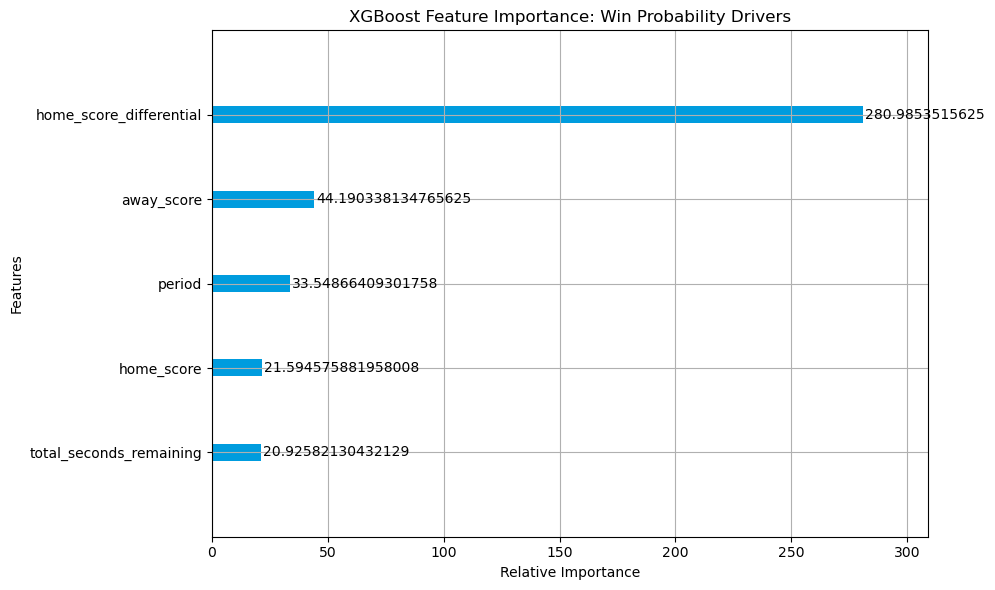

In [49]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

## setting up the visual canvas size (width, height)
fig, ax = plt.subplots(figsize=(10, 6))

## Plotting the feature importance using the "gain" metric 
## gain measures the improvement in accuracy the feature provides
plot_importance(
 xgb_model,
 ax=ax, 
 importance_type = 'gain',
 title = "XGBoost Feature Importance: Win Probability Drivers",
 xlabel = "Relative Importance",
 color = '#009CDE'
)

plt.tight_layout()
plt.show()

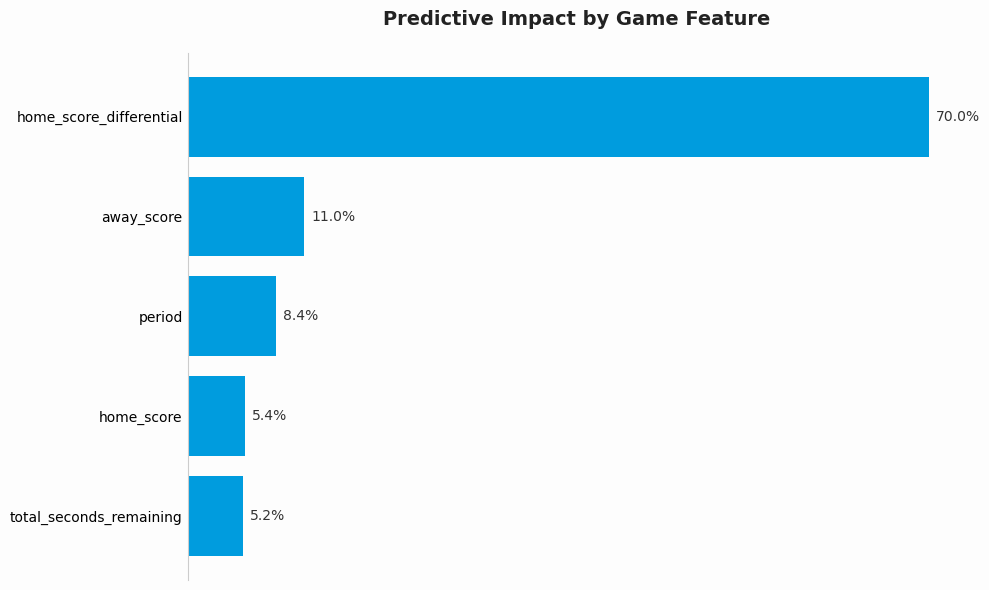

In [50]:
importances = xgb_model.feature_importances_
features = X_train.columns 

importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending = True)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#fdfdfd')
ax.set_facecolor('#fdfdfd')

bars = ax.barh(importances_df['Feature'], importances_df['Importance'], color='#009CDE')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_color('#cccccc')

percentage_lables = [f"{(val * 100):.1f}%" for val in importances_df['Importance']]

ax.bar_label(bars, labels=percentage_lables, padding =5, color='#333333', fontsize =10)

plt.title('Predictive Impact by Game Feature', fontsize=14, pad=20, weight='bold', color='#222222')
plt.xticks([])
plt.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()


# Visualization

In [51]:
import matplotlib.pyplot as plt

In [52]:
original_test_data = X.iloc[test_idx].copy()

original_test_data['win_proability'] = xgb_y_pred_proba

In [53]:
sample_game_id = original_test_data['game_id'].iloc[0]

In [54]:
single_game = original_test_data[original_test_data['game_id'] == sample_game_id].copy()

single_game = single_game.sort_values('total_seconds_remaining', ascending = False)

In [55]:
home_team = single_game['home_name'].iloc[0]

away_team = single_game['away_name'].iloc[0]

/var/folders/9m/d92m8dks0fb4fq5pygy1wsq40000gp/T/ipykernel_19868/3668830789.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels([f"{(y*100):.0f}%" for y in ax1.get_yticks()])


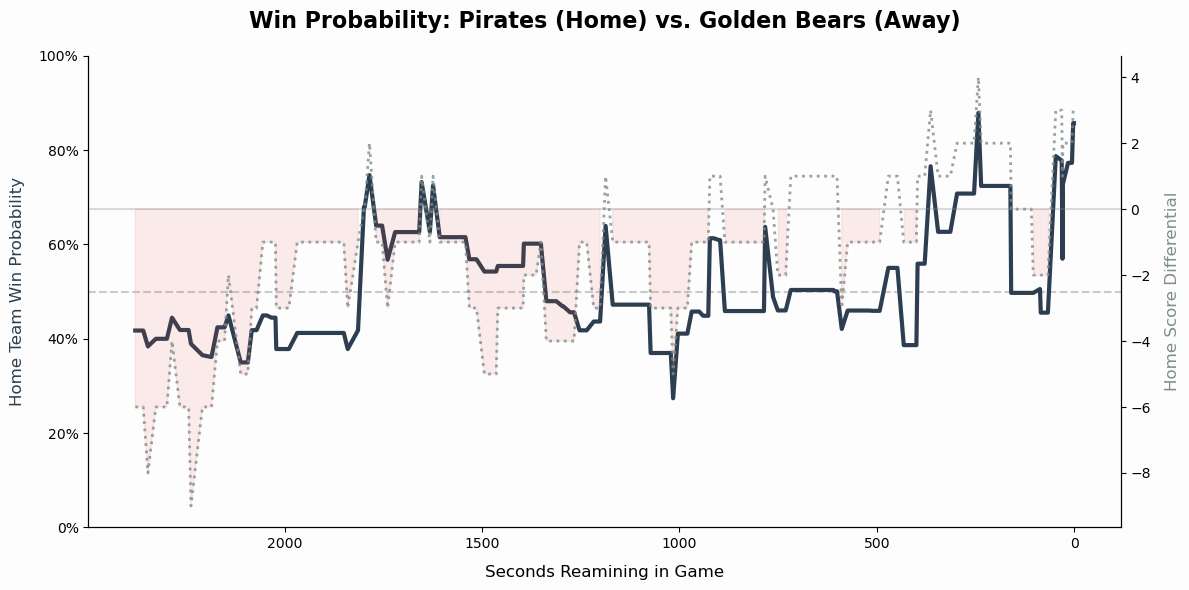

In [57]:
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#fdfdfd')
ax1.set_facecolor('#fdfdfd')

ax1.plot(
    single_game['total_seconds_remaining'],
    single_game['win_proability'],
    color='#2C3E50', 
    linewidth=3,
    zorder=3
)

ax1.invert_xaxis()
ax1.set_ylim(0,1)

ax1.set_ylabel("Home Team Win Probability", fontsize = 12, color = '#2c3e50', labelpad=10)
ax1.set_yticklabels([f"{(y*100):.0f}%" for y in ax1.get_yticks()])

ax2 = ax1.twinx()

ax2.plot(
    single_game['total_seconds_remaining'],
    single_game['home_score_differential'],
    color = '#7f8c8d',
    linestyle = ':',
    linewidth = 2, 
    alpha = 0.8, 
    zorder=2
)

ax2.fill_between(
    single_game['total_seconds_remaining'],
    single_game['home_score_differential'],
    0,
    where = (single_game['home_score_differential'] <0),
    color='#e74c3c', 
    alpha=0.1
)

ax2.set_ylabel("Home Score Differential", fontsize=12, color='#7f8c8d', labelpad=10)

ax1.axhline(0.5, color = '#999999', linestyle = '--', alpha = 0.5)
ax2.axhline(0, color='#7f8c8d', linestyle='-', alpha=0.3)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible("#cccccc")
ax1.spines['left'].set_visible('#cccccc')
ax2.spines['right'].set_visible('#cccccc')

ax1.set_title(f"Win Probability: {home_team} (Home) vs. {away_team} (Away)", fontsize = 16, weight = 'bold', pad=20)
ax1.set_xlabel(f"Seconds Reamining in Game", fontsize = 12, labelpad=10)



plt.tight_layout()
plt.show()